In [9]:
import numpy as np
import numba as nb
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import re

from tqdm import tqdm

# ----------------------------
# Settings
# ----------------------------
n_paths_max = 10000
dt = 1.0  # one calendar-day step (used for OLS calibration on trading-day data)
seed = 123

forward_csv_path = "../data/forward_prices.csv"

# ----------------------------
# Load spot data (trading days) for OLS calibration
# ----------------------------
with open("../data/THE_gas.txt", "r", encoding="utf-8") as f:
    txt = " ".join(f.readlines())

dates_str = re.search(r"labels:\s*\[(.*?)\]", txt).group(1)
dates = [d.replace("'", "").strip() for d in dates_str.split(",")]

prices_str = re.search(r"data:\s*\[(.*?)\]", txt).group(1)
prices = [p.strip() for p in prices_str.split(",")]
prices = [np.nan if p == "" else float(p) for p in prices]

data = pd.DataFrame({
    "date":       pd.to_datetime(dates, format="%d.%m.%Y"),
    "spot_price": prices,
})

data = (
    data
    .dropna(subset=["spot_price"])
    .loc[(data["date"] >= "2024-01-02") & (data["date"] <= "2025-12-31")]
    .sort_values("date")
    .drop_duplicates(subset=["date"])
    .reset_index(drop=True)
)

# ----------------------------
# Load forward curve
# ----------------------------
forward_curve = pd.read_csv(forward_csv_path)
forward_curve["date"] = pd.to_datetime(forward_curve["date"]).dt.normalize()

# ----------------------------
# Joint estimation of seasonality + AR(1)  [trading days]
# ----------------------------
data["t"]     = (data["date"] - data["date"].iloc[0]).dt.days.astype(float)
data["X"]     = np.log(data["spot_price"].astype(float))
data["X_lag"] = data["X"].shift(1)

reg_df = data.dropna(subset=["X", "X_lag"]).copy()
t_reg  = reg_df["t"].to_numpy()

sin1 = np.sin(2.0 * np.pi * t_reg / 365.0)
cos1 = np.cos(2.0 * np.pi * t_reg / 365.0)

Xreg      = sm.add_constant(np.column_stack([reg_df["X_lag"].to_numpy(), sin1, cos1]))
fit_joint = sm.OLS(reg_df["X"].to_numpy(), Xreg).fit()

const_hat     = float(fit_joint.params[0])
b_hat         = float(fit_joint.params[1])
c1_hat        = float(fit_joint.params[2])
c2_hat        = float(fit_joint.params[3])
sigma_eta_hat = float(np.std(fit_joint.resid, ddof=1))

kappa_hat = -np.log(b_hat) / dt
sigma_hat = np.sqrt(
    (sigma_eta_hat**2) * 2.0 * kappa_hat / (1.0 - np.exp(-2.0 * kappa_hat * dt))
)

# ----------------------------
# Build calendar-day simulation grid
# (forward_prices.csv already has all calendar days — direct merge)
# ----------------------------
_cal_start = data["date"].iloc[0]
_cal_end   = data["date"].iloc[-1]
sim_df = pd.DataFrame({"date": pd.date_range(_cal_start, _cal_end, freq="D")})
sim_df = sim_df.merge(forward_curve, on="date", how="inner")
sim_df = sim_df.sort_values("date").reset_index(drop=True)

data  = sim_df.copy()
data["t"]   = (data["date"] - data["date"].iloc[0]).dt.days.astype(float)
data["F0t"] = data["forward_price"].astype(float)

Tn    = len(data)
t_arr = data["t"].to_numpy()

var_X  = (sigma_hat**2 / (2.0 * kappa_hat)) * (1.0 - np.exp(-2.0 * kappa_hat * t_arr))
m      = np.log(data["F0t"].to_numpy()) - 0.5 * var_X
m_col  = m[:, None]

# ----------------------------
# Simulate paths (antithetic normals)
# ----------------------------
rng    = np.random.default_rng(seed)
n_half = int(np.ceil(n_paths_max / 2))
Z_half = rng.standard_normal(size=(Tn - 1, n_half))
Z      = np.concatenate([Z_half, -Z_half], axis=1)[:, :n_paths_max]

def simulate_from_Z(Z, *, n_paths, Tn, t_arr, kappa_hat, sigma_hat, m_col):
    Z_use = Z[:, :n_paths]
    Y = np.zeros((Tn, n_paths), dtype=np.float64)
    for i in range(1, Tn):
        h     = t_arr[i] - t_arr[i - 1]
        phi_h = np.exp(-kappa_hat * h)
        sd_h  = np.sqrt(sigma_hat**2 / (2.0 * kappa_hat) * (1.0 - np.exp(-2.0 * kappa_hat * h)))
        Y[i]  = phi_h * Y[i - 1] + sd_h * Z_use[i - 1]
    return np.exp(Y + m_col)

# ============================================================
# MODEL PARAMETERS — defined before any arrays that depend on them
# ============================================================
alpha_c          = 10_000.0
refine_factor    = 4
alpha_f          = alpha_c / refine_factor   # 2 500

r_annual         = 0.1
basis_degree     = 3
terminal_penalty = -np.inf

# Step-varying discount: 
disc_arr = np.exp(-r_annual * np.diff(t_arr) / 365.0)   # shape (T,), disc_arr[t] for step t->t+1

# ============================================================
# Constraint helpers
# ============================================================

# ---------- vmax: constant ----------
VMAX_CONST = 10_125_000.0

# ---------- Rate caps ----------
INJECTMAX_BASE = 3_780.0 * 24.0
WDRMAX_BASE    = 7_500.0 * 24.0

# ---------- vmin: technical-feasibility floor from dated anchors ----------
# VMIN_BASE = 1_312_027.0
VMIN_BASE = 0.0
_VMIN_CYCLE_START  = pd.Timestamp("2024-01-01")
_VMIN_CYCLE_LENGTH = 365 + 366

# Anchor dates are exact calendar dates — no snapping needed.
_RAW_ANCHOR_DATES = pd.to_datetime([
    "2024-02-01",
    "2024-05-01",
    "2024-07-01",
    "2024-09-01",
    "2024-11-01",
    "2025-02-01",
    "2025-05-01",
    "2025-07-01",
    "2025-09-01",
    "2025-11-01",
])
_VMIN_ANCHOR_DATES = pd.DatetimeIndex(_RAW_ANCHOR_DATES)
_VMIN_ANCHOR_VALUES = VMAX_CONST * np.array([
    0.0, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0,
], dtype=np.float64)
_VMIN_ANCHOR_X = (_VMIN_ANCHOR_DATES - _VMIN_CYCLE_START).days.to_numpy()
# Include previous/current/next cycles so the floor respects both
# backward-looking withdrawal feasibility and forward-looking injection
# feasibility across the two-year repeating pattern.
_VMIN_ANCHOR_X_ALL = np.r_[
    _VMIN_ANCHOR_X - _VMIN_CYCLE_LENGTH,
    _VMIN_ANCHOR_X,
    _VMIN_ANCHOR_X + _VMIN_CYCLE_LENGTH,
]
_VMIN_ANCHOR_Y_ALL = np.r_[
    _VMIN_ANCHOR_VALUES,
    _VMIN_ANCHOR_VALUES,
    _VMIN_ANCHOR_VALUES,
]

def feasible_vmin_for_dates(dates_like) -> np.ndarray:
    dates = pd.DatetimeIndex(dates_like)
    date_x = (dates - _VMIN_CYCLE_START).days.to_numpy()
    feasible_floor = np.empty(len(dates), dtype=np.float64)
    inj_max = INJECTMAX_BASE
    wdr_max = WDRMAX_BASE
    for i, t in enumerate(date_x):
        future_mask = _VMIN_ANCHOR_X_ALL >= t
        past_mask   = _VMIN_ANCHOR_X_ALL <= t

        days_to_future = _VMIN_ANCHOR_X_ALL[future_mask] - t
        days_from_past = t - _VMIN_ANCHOR_X_ALL[past_mask]

        required_for_future = (
            _VMIN_ANCHOR_Y_ALL[future_mask] - inj_max * days_to_future
        ).max()
        required_from_past = (
            _VMIN_ANCHOR_Y_ALL[past_mask] - wdr_max * days_from_past
        ).max()

        feasible_floor[i] = np.clip(
            max(required_for_future, required_from_past),
            VMIN_BASE,
            VMAX_CONST,
        )
    return feasible_floor

def vmin_at_date(date: pd.Timestamp) -> float:
    return float(feasible_vmin_for_dates(pd.DatetimeIndex([date]))[0])

def inj_cap(fill_frac: float) -> float:
    return (0.75 if fill_frac >= 0.95 else 1.00) * INJECTMAX_BASE

def wdr_cap(fill_frac: float) -> float:
    if   fill_frac <= 0.05:  cap = 0.25
    elif fill_frac <= 0.125: cap = 0.50
    elif fill_frac <= 0.15:  cap = 0.75
    elif fill_frac <= 0.20:  cap = 0.85
    else:                    cap = 1.00
    return cap * WDRMAX_BASE

# ============================================================
# Per-date constraint arrays
# ============================================================
dates_pd = pd.DatetimeIndex(data["date"].to_numpy())

vmax_arr = np.full(len(dates_pd), VMAX_CONST, dtype=np.float64)
vmin_arr = feasible_vmin_for_dates(dates_pd)

# v0 and vT_target: fixed level, snapped to fine grid
v_target_raw = 9_153_925.0
v0        = round(v_target_raw / alpha_f) * alpha_f
vT_target = round(v_target_raw / alpha_f) * alpha_f

print(f"v0        = {v0:>12,.0f}  (snapped from {v_target_raw:,.0f})")
print(f"vT_target = {vT_target:>12,.0f}  (snapped from {v_target_raw:,.0f})")
print(f"vmax range: {vmax_arr.min():,.0f} – {vmax_arr.max():,.0f}")
print(f"vmin range: {vmin_arr.min():,.0f} – {vmin_arr.max():,.0f}")


# ============================================================
# Volume grid
# ============================================================
VMIN_GLOBAL = 0.0
VMAX_GLOBAL = float(np.max(vmax_arr))

Nc = int(round((VMAX_GLOBAL - VMIN_GLOBAL) / alpha_c)) + 1
Nf = (Nc - 1) * refine_factor + 1

v_coarse        = VMIN_GLOBAL + alpha_c * np.arange(Nc, dtype=np.float64)
v_fine          = VMIN_GLOBAL + alpha_f * np.arange(Nf, dtype=np.float64)
coarse_fine_idx = (refine_factor * np.arange(Nc)).astype(np.int32)
assert coarse_fine_idx[-1] == Nf - 1, "Grid alignment check failed"

def fine_index_of(v: float) -> int:
    return int(round((v - VMIN_GLOBAL) / alpha_f))

n0_f  = fine_index_of(v0)
nT_f  = fine_index_of(vT_target)

print(f"\nGrid: Nc={Nc}, Nf={Nf}, n0_f={n0_f}, nT_f={nT_f}")

# ============================================================
# Terminal value: hard target at nT_f.
# ============================================================
def terminal_value(v_arr: np.ndarray) -> np.ndarray:
    tv = np.full_like(v_arr, terminal_penalty, dtype=np.float64)
    tv[nT_f] = 0.0
    return tv

# ============================================================
# Feasible action sets — one per timestep
# ============================================================
def build_feasible_actions_at_t(t_idx: int):
    """
    Transition t → t+1.
    Origin:      vmin(t)   <= v  <= vmax(t)
    Destination: vmin(t+1) <= v' <= vmax(t+1)
    Rate caps are scaled by the number of calendar days in the step so that
    weekend/holiday gaps (e.g. Fri→Mon = 3 days) correctly allow 3× the
    daily injection/withdrawal capacity.
    """
    vm_t    = vmax_arr[t_idx]
    vn_t    = vmin_arr[t_idx]
    t_next  = min(t_idx + 1, len(vmax_arr) - 1)
    vm_next = vmax_arr[t_next]
    vn_next = vmin_arr[t_next]

    days = float(t_arr[t_next] - t_arr[t_idx]) if t_next != t_idx else 1.0
    days = max(days, 1.0)

    # First pass: determine K_max
    K_max_t = 0
    for n_f in range(Nf):
        v = v_fine[n_f]
        if v < vn_t - 1e-6 or v > vm_t + 1e-6:
            continue
        fill          = v / vm_t
        max_inj_total = inj_cap(fill) * days
        max_wdr_total = wdr_cap(fill) * days
        dv_lo = max(vn_next - v, -max_wdr_total)
        dv_hi = min(vm_next - v,  max_inj_total)
        k_lo  = int(np.ceil(dv_lo  / alpha_f))
        k_hi  = int(np.floor(dv_hi / alpha_f))
        K_max_t = max(K_max_t, max(0, k_hi - k_lo + 1))

    K_max_t = max(K_max_t, 1)

    next_idx = np.full((Nf, K_max_t), -1, dtype=np.int32)
    dv_mat   = np.zeros((Nf, K_max_t), dtype=np.float64)
    K_len    = np.zeros(Nf, dtype=np.int32)

    for n_f in range(Nf):
        v = v_fine[n_f]
        if v < vn_t - 1e-6 or v > vm_t + 1e-6:
            continue
        fill          = v / vm_t
        max_inj_total = inj_cap(fill) * days
        max_wdr_total = wdr_cap(fill) * days
        dv_lo = max(vn_next - v, -max_wdr_total)
        dv_hi = min(vm_next - v,  max_inj_total)
        k_lo  = int(np.ceil(dv_lo  / alpha_f))
        k_hi  = int(np.floor(dv_hi / alpha_f))
        if k_hi < k_lo:
            continue
        idxs = n_f + np.arange(k_lo, k_hi + 1, dtype=np.int32)
        idxs = idxs[(idxs >= 0) & (idxs < Nf)]
        k    = idxs.size
        K_len[n_f] = k
        if k:
            next_idx[n_f, :k] = idxs
            dv_mat[n_f,   :k] = v_fine[idxs] - v

    return next_idx, dv_mat, K_len


print("Pre-computing feasible action sets …")
all_next_idx = []
all_dv_mat   = []
all_K_len    = []
all_dest_ok  = []

for t_idx in range(Tn):
    ni, dv, kl = build_feasible_actions_at_t(t_idx)
    all_next_idx.append(ni)
    all_dv_mat.append(dv)
    all_K_len.append(kl)

    t_next  = min(t_idx + 1, len(vmax_arr) - 1)
    all_dest_ok.append(
        (v_fine >= vmin_arr[t_next] - 1e-6) &
        (v_fine <= vmax_arr[t_next] + 1e-6)
    )

T = Tn - 1
all_can_reach = [np.zeros(Nf, dtype=np.bool_) for _ in range(T + 1)]
all_can_reach[T][nT_f] = True
for t_idx in range(T - 1, -1, -1):
    can_reach_next = all_can_reach[t_idx + 1]
    can_reach_now  = all_can_reach[t_idx]
    ni_t = all_next_idx[t_idx]
    kl_t = all_K_len[t_idx]
    for n_f in range(Nf):
        klen = kl_t[n_f]
        if klen == 0:
            continue
        can_reach_now[n_f] = np.any(can_reach_next[ni_t[n_f, :klen]])

print("Done.")

# ============================================================
# Numba kernels
# ============================================================

@nb.njit(parallel=True, fastmath=True)
def interpolate_coarse_to_fine(C_hat_fine_buf, C_hat_coarse,
                                coarse_fine_idx, refine_factor):
    M, Nc = C_hat_coarse.shape
    for i in nb.prange(M):
        for k in range(Nc):
            C_hat_fine_buf[i, coarse_fine_idx[k]] = C_hat_coarse[i, k]
    if refine_factor == 1:
        return
    for i in nb.prange(M):
        for k in range(Nc - 1):
            lf    = coarse_fine_idx[k]
            left  = C_hat_coarse[i, k]
            right = C_hat_coarse[i, k + 1]
            for j in range(1, refine_factor):
                w = j / refine_factor
                C_hat_fine_buf[i, lf + j] = (1.0 - w) * left + w * right


@nb.njit(parallel=True, fastmath=True)
def clamp_infeasible(C_hat_fine_buf, dest_ok, terminal_penalty):
    M  = C_hat_fine_buf.shape[0]
    Nf = C_hat_fine_buf.shape[1]
    for i in nb.prange(M):
        for n in range(Nf):
            if not dest_ok[n]:
                C_hat_fine_buf[i, n] = terminal_penalty


@nb.njit(parallel=True, fastmath=True)
def bellman_update_numba(Y_current, Y_next, pi_next_idx_t, n_curr, S_t, C_hat_fine,
                         next_idx_mat, dv_mat, K_len, disc_t, terminal_penalty):
    M  = S_t.shape[0]
    Nf = next_idx_mat.shape[0]
    for i in nb.prange(M):
        s          = S_t[i]
        n_realized = n_curr[i]
        pi_next_idx_t[i] = -1
        for n_f in range(Nf):
            klen = K_len[n_f]
            if klen == 0:
                Y_current[i, n_f] = terminal_penalty
                continue
            best_val  = terminal_penalty
            best_next = -1
            best_dv   = 0.0
            for k in range(klen):
                nxt = next_idx_mat[n_f, k]
                dv  = dv_mat[n_f, k]
                cand = (-s * dv) + C_hat_fine[i, nxt]
                if cand > best_val:
                    best_val  = cand
                    best_next = nxt
                    best_dv   = dv
            Y_current[i, n_f] = (-s * best_dv) + disc_t * Y_next[i, best_next]
            if n_f == n_realized:
                pi_next_idx_t[i] = best_next



@nb.njit(parallel=True, fastmath=True)
def fit_ols_coarse(X, Y_disc, reach_next, coarse_fine_idx, B):
    M  = X.shape[0]
    p  = X.shape[1]
    Nc = B.shape[1]
    for j in nb.prange(Nc):
        if not reach_next[coarse_fine_idx[j]]:
            continue
        cnt = 0
        for i in range(M):
            if np.isfinite(Y_disc[i, j]):
                cnt += 1
        if cnt < 4:
            continue
        Xm = np.empty((cnt, p), dtype=np.float64)
        ym = np.empty(cnt,      dtype=np.float64)
        k  = 0
        for i in range(M):
            v = Y_disc[i, j]
            if np.isfinite(v):
                for c in range(p):
                    Xm[k, c] = X[i, c]
                ym[k] = v
                k    += 1
        XtX = Xm.T @ Xm
        XtY = Xm.T @ ym
        B[:, j] = np.linalg.solve(XtX, XtY)

@nb.njit(parallel=True, fastmath=True)
def forward_simulate_paths(n_path_idx, S, B_store, coarse_fine_idx,
                            refine_factor, next_idx_mat_list, dv_mat_list,
                            K_len_list, dest_ok_list, n0_f,
                            C_hat_fine_buf, terminal_penalty):
    Tloc   = B_store.shape[0]
    Mloc   = S.shape[1]
    Nc_loc = B_store.shape[2]
    Nf_loc = C_hat_fine_buf.shape[1]

    for i in nb.prange(Mloc):
        n_path_idx[0, i] = n0_f

    for t in range(Tloc):
        for i in nb.prange(Mloc):
            s  = S[t, i]
            s2 = s * s
            s3 = s2 * s
            for k in range(Nc_loc):
                C_hat_fine_buf[i, coarse_fine_idx[k]] = (
                    B_store[t, 0, k]
                    + s  * B_store[t, 1, k]
                    + s2 * B_store[t, 2, k]
                    + s3 * B_store[t, 3, k]
                )

        if refine_factor != 1:
            for i in nb.prange(Mloc):
                for k in range(Nc_loc - 1):
                    lf    = coarse_fine_idx[k]
                    left  = C_hat_fine_buf[i, lf]
                    right = C_hat_fine_buf[i, coarse_fine_idx[k + 1]]
                    for j in range(1, refine_factor):
                        w = j / refine_factor
                        C_hat_fine_buf[i, lf + j] = (1.0 - w) * left + w * right

        dok = dest_ok_list[t]
        for i in nb.prange(Mloc):
            for n in range(Nf_loc):
                if not dok[n]:
                    C_hat_fine_buf[i, n] = terminal_penalty

        ni_t = next_idx_mat_list[t]
        dv_t = dv_mat_list[t]
        kl_t = K_len_list[t]

        for i in nb.prange(Mloc):
            n    = n_path_idx[t, i]
            klen = kl_t[n]
            s    = S[t, i]
            best_val  = terminal_penalty
            best_next = -1
            for kk in range(klen):
                nxt = ni_t[n, kk]
                dv  = dv_t[n, kk]
                cand = (-s * dv) + C_hat_fine_buf[i, nxt]
                if cand > best_val:
                    best_val  = cand
                    best_next = nxt
            n_path_idx[t + 1, i] = best_next if best_next != -1 else n


# ============================================================
# LSMC main function
# ============================================================
def lsmc_value_and_paths_given_S(S: np.ndarray):
    T = S.shape[0] - 1
    M = S.shape[1]

    C_hat_fine_buf = np.empty((M, Nf), dtype=np.float64)

    # ---- Terminal condition ----
    tv        = terminal_value(v_fine)
    Y_next    = np.tile(tv, (M, 1))
    Y_next[:, ~all_dest_ok[-1]] = terminal_penalty

    Y_current   = np.empty((M, Nf), dtype=np.float64)
    pi_dtype    = np.int16 if Nf <= np.iinfo(np.int16).max else np.int32
    pi_next_idx = np.empty((T, M), dtype=pi_dtype)
    n_curr      = np.full(M, nT_f, dtype=np.int32)

    p_dim   = basis_degree + 1
    B_store = np.empty((T, p_dim, Nc), dtype=np.float64)

    # ---- Backward pass ----
    for t in tqdm(range(T - 1, -1, -1), desc="Backward pass"):
        S_t = S[t].astype(np.float64, copy=False)

        X       = np.empty((M, 4), dtype=np.float64)
        X[:, 0] = 1.0
        X[:, 1] = S_t
        X[:, 2] = S_t * S_t
        X[:, 3] = X[:, 2] * S_t

        reach_next = all_can_reach[t + 1]
        Y_disc = disc_arr[t] * Y_next[:, coarse_fine_idx]
        B      = np.zeros((4, Nc), dtype=np.float64)
        fit_ols_coarse(X, Y_disc, reach_next, coarse_fine_idx, B)
        B_store[t] = B

        C_hat_coarse = X @ B
        interpolate_coarse_to_fine(C_hat_fine_buf, C_hat_coarse,
                                   coarse_fine_idx, refine_factor)
        clamp_infeasible(C_hat_fine_buf, reach_next, terminal_penalty)

        bellman_update_numba(
            Y_current, Y_next, pi_next_idx[t], n_curr, S_t,
            C_hat_fine_buf, all_next_idx[t], all_dv_mat[t], all_K_len[t],
            disc_arr[t], terminal_penalty,
        )

        n_curr = pi_next_idx[t].astype(np.int32)
        Y_next, Y_current = Y_current, Y_next

    V0_hat = float(np.mean(Y_next[:, n0_f]))

    # ---- Forward rollout ----
    ni_list       = nb.typed.List()
    dv_list       = nb.typed.List()
    kl_list       = nb.typed.List()
    reach_ok_list = nb.typed.List()
    for t in range(T):
        ni_list.append(all_next_idx[t])
        dv_list.append(all_dv_mat[t])
        kl_list.append(all_K_len[t])
        reach_ok_list.append(all_can_reach[t + 1])

    n_path_idx = np.empty((T + 1, M), dtype=np.int32)
    forward_simulate_paths(
        n_path_idx, S, B_store, coarse_fine_idx, refine_factor,
        ni_list, dv_list, kl_list, reach_ok_list,
        n0_f, C_hat_fine_buf, terminal_penalty
    )

    v_path = v_fine[n_path_idx]
    return V0_hat, v_path, data["date"].to_numpy(), B_store

# ============================================================
# Run once: simulate S, value, then plot inventory band
# ============================================================
S_sim = simulate_from_Z(Z, n_paths=n_paths_max, Tn=Tn, t_arr=t_arr,
                        kappa_hat=kappa_hat, sigma_hat=sigma_hat, m_col=m_col)
V0_hat, v_path, dates, B_store = lsmc_value_and_paths_given_S(S_sim)
print("V0_hat =", V0_hat)

# np.savez_compressed("../data/realised_paths_OLS_GSD.npz", v_path=v_path, dates=dates)
# np.savez_compressed("../data/B_store_OLS_GSD.npz", B_store=B_store)

v0        =    9,155,000  (snapped from 9,153,925)
vT_target =    9,155,000  (snapped from 9,153,925)
vmax range: 10,125,000 – 10,125,000
vmin range: 0 – 0

Grid: Nc=1013, Nf=4049, n0_f=3662, nT_f=3662
Pre-computing feasible action sets …
Done.


Backward pass: 100%|██████████| 729/729 [05:08<00:00,  2.36it/s]


V0_hat = 163890472.3288216


In [ ]:
# ============================================================
# Grid convergence study: vary alpha_c, keep alpha_f = 2500 fixed
# refine_factor = alpha_c / 2500 is updated each iteration so the
# fine grid spacing is always 2500 MWh regardless of coarse spacing.
# Coarsest -> finest so the loop ends at the original state.
# ============================================================
import time

_alpha_c_candidates = [80000, 60000, 40000, 30000, 20000, 15000, 10000]
convergence_results = []

ALPHA_F_FINE = 2_500.0   # fine grid spacing — held constant

for _alpha_c_val in _alpha_c_candidates:
    # ---- rebuild grid globals ----
    alpha_c         = float(_alpha_c_val)
    refine_factor   = int(round(alpha_c / ALPHA_F_FINE))
    alpha_f         = alpha_c / refine_factor          # == ALPHA_F_FINE
    Nc              = int(round((VMAX_GLOBAL - VMIN_GLOBAL) / alpha_c)) + 1
    Nf              = (Nc - 1) * refine_factor + 1
    v_coarse        = VMIN_GLOBAL + alpha_c * np.arange(Nc, dtype=np.float64)
    v_fine          = VMIN_GLOBAL + alpha_f * np.arange(Nf, dtype=np.float64)
    coarse_fine_idx = (refine_factor * np.arange(Nc)).astype(np.int32)
    assert coarse_fine_idx[-1] == Nf - 1
    assert abs(alpha_f - ALPHA_F_FINE) < 1e-6, f'alpha_f={alpha_f} != {ALPHA_F_FINE}'

    # snap starting / terminal inventory to new fine grid
    n0_f = int(round((v_target_raw - VMIN_GLOBAL) / alpha_f))
    nT_f = int(round((v_target_raw - VMIN_GLOBAL) / alpha_f))

    # ---- rebuild feasible-action sets ----
    print(f"\nalpha_c={alpha_c:>8,.0f}  Nc={Nc:>5d}  Nf={Nf:>6d}")
    print("  Pre-computing feasible action sets...", end=" ", flush=True)
    t_fa = time.perf_counter()

    all_next_idx = []
    all_dv_mat   = []
    all_K_len    = []
    all_dest_ok  = []
    for t_idx in range(Tn):
        ni, dv, kl = build_feasible_actions_at_t(t_idx)
        all_next_idx.append(ni)
        all_dv_mat.append(dv)
        all_K_len.append(kl)
        t_next = min(t_idx + 1, len(vmax_arr) - 1)
        all_dest_ok.append(
            (v_fine >= vmin_arr[t_next] - 1e-6) &
            (v_fine <= vmax_arr[t_next] + 1e-6)
        )

    all_can_reach = [np.zeros(Nf, dtype=np.bool_) for _ in range(T + 1)]
    all_can_reach[T][nT_f] = True
    for t_idx in range(T - 1, -1, -1):
        can_reach_next = all_can_reach[t_idx + 1]
        can_reach_now  = all_can_reach[t_idx]
        ni_t = all_next_idx[t_idx]
        kl_t = all_K_len[t_idx]
        for n_f in range(Nf):
            klen = kl_t[n_f]
            if klen == 0:
                continue
            can_reach_now[n_f] = np.any(can_reach_next[ni_t[n_f, :klen]])

    print(f"done ({time.perf_counter()-t_fa:.1f}s)")

    # ---- run LSMC ----
    t0 = time.perf_counter()
    V0_hat_nc, _, _, _ = lsmc_value_and_paths_given_S(S_sim)
    elapsed = time.perf_counter() - t0

    convergence_results.append({
        "alpha_c": int(alpha_c), "Nc": Nc, "Nf": Nf,
        "V0_hat": V0_hat_nc, "time_s": elapsed,
    })
    print(f"  V0_hat = {V0_hat_nc:>14,.2f} EUR   ({elapsed:.1f}s)")

# ---- summary table ----
df_conv = pd.DataFrame(convergence_results)
print("\n--- Convergence summary ---")
print(df_conv.to_string(index=False))

# ---- plot ----
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif":  ["Computer Modern Roman"],
})

baseline_V0 = df_conv.loc[df_conv["Nc"].idxmax(), "V0_hat"]
df_conv["rel_error_pct"] = 100.0 * (df_conv["V0_hat"] - baseline_V0) / abs(baseline_V0)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), dpi=200)

axes[0].plot(df_conv["Nc"], df_conv["V0_hat"] / 1e6,
             marker="o", color="steelblue", lw=1.2)
axes[0].set_xlabel(r"$N_c$ (coarse nodes)")
axes[0].set_ylabel(r"$\hat{V}_0$ (EUR, millions)")
axes[0].set_title("Value vs. grid size")
axes[0].grid(True)

axes[1].plot(df_conv["Nc"], df_conv["rel_error_pct"],
             marker="o", color="firebrick", lw=1.2)
axes[1].axhline(0, ls="--", lw=0.8, color="black")
axes[1].set_xlabel(r"$N_c$ (coarse nodes)")
axes[1].set_ylabel(r"Relative error (\%)")
axes[1].set_title(r"Error relative to $N_c = 1013$ baseline")
axes[1].grid(True)

axes[2].plot(df_conv["Nc"], df_conv["time_s"],
             marker="o", color="darkorange", lw=1.2)
axes[2].set_xlabel(r"$N_c$ (coarse nodes)")
axes[2].set_ylabel("Running time (s)")
axes[2].set_title("Runtime vs. grid size")
axes[2].grid(True)

fig.tight_layout()
plt.savefig("../../fig/Plots/OLS_grid_convergence_GSD.png")
plt.show()



alpha_c=  80,000  Nc=  128  Nf=  4065
  Pre-computing feasible action sets... 

KeyboardInterrupt: 

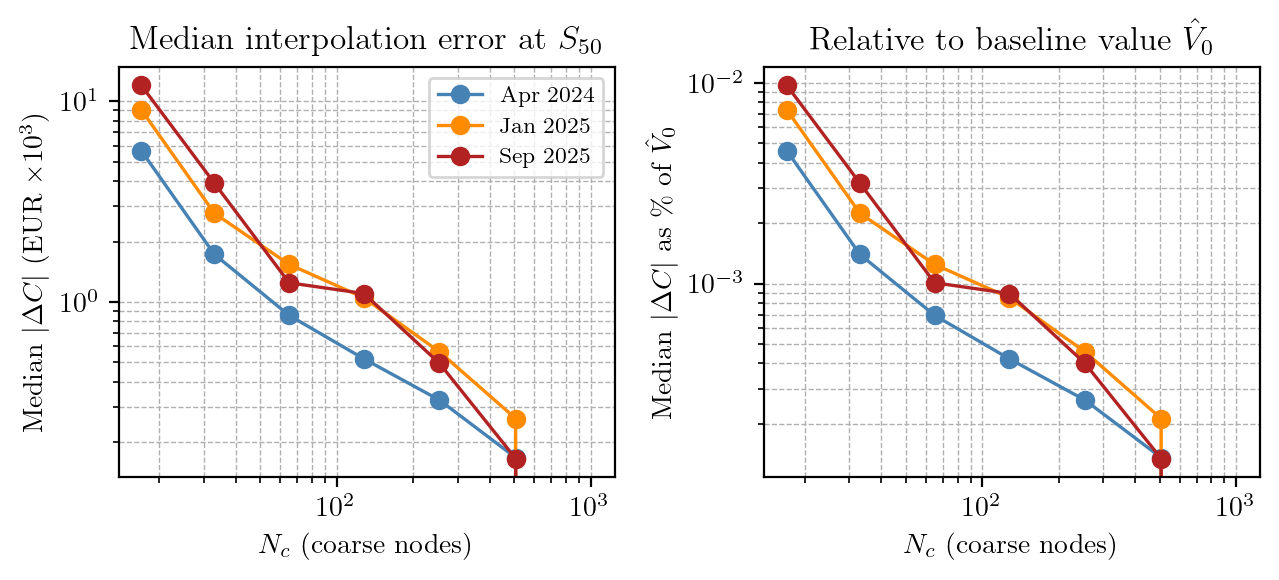

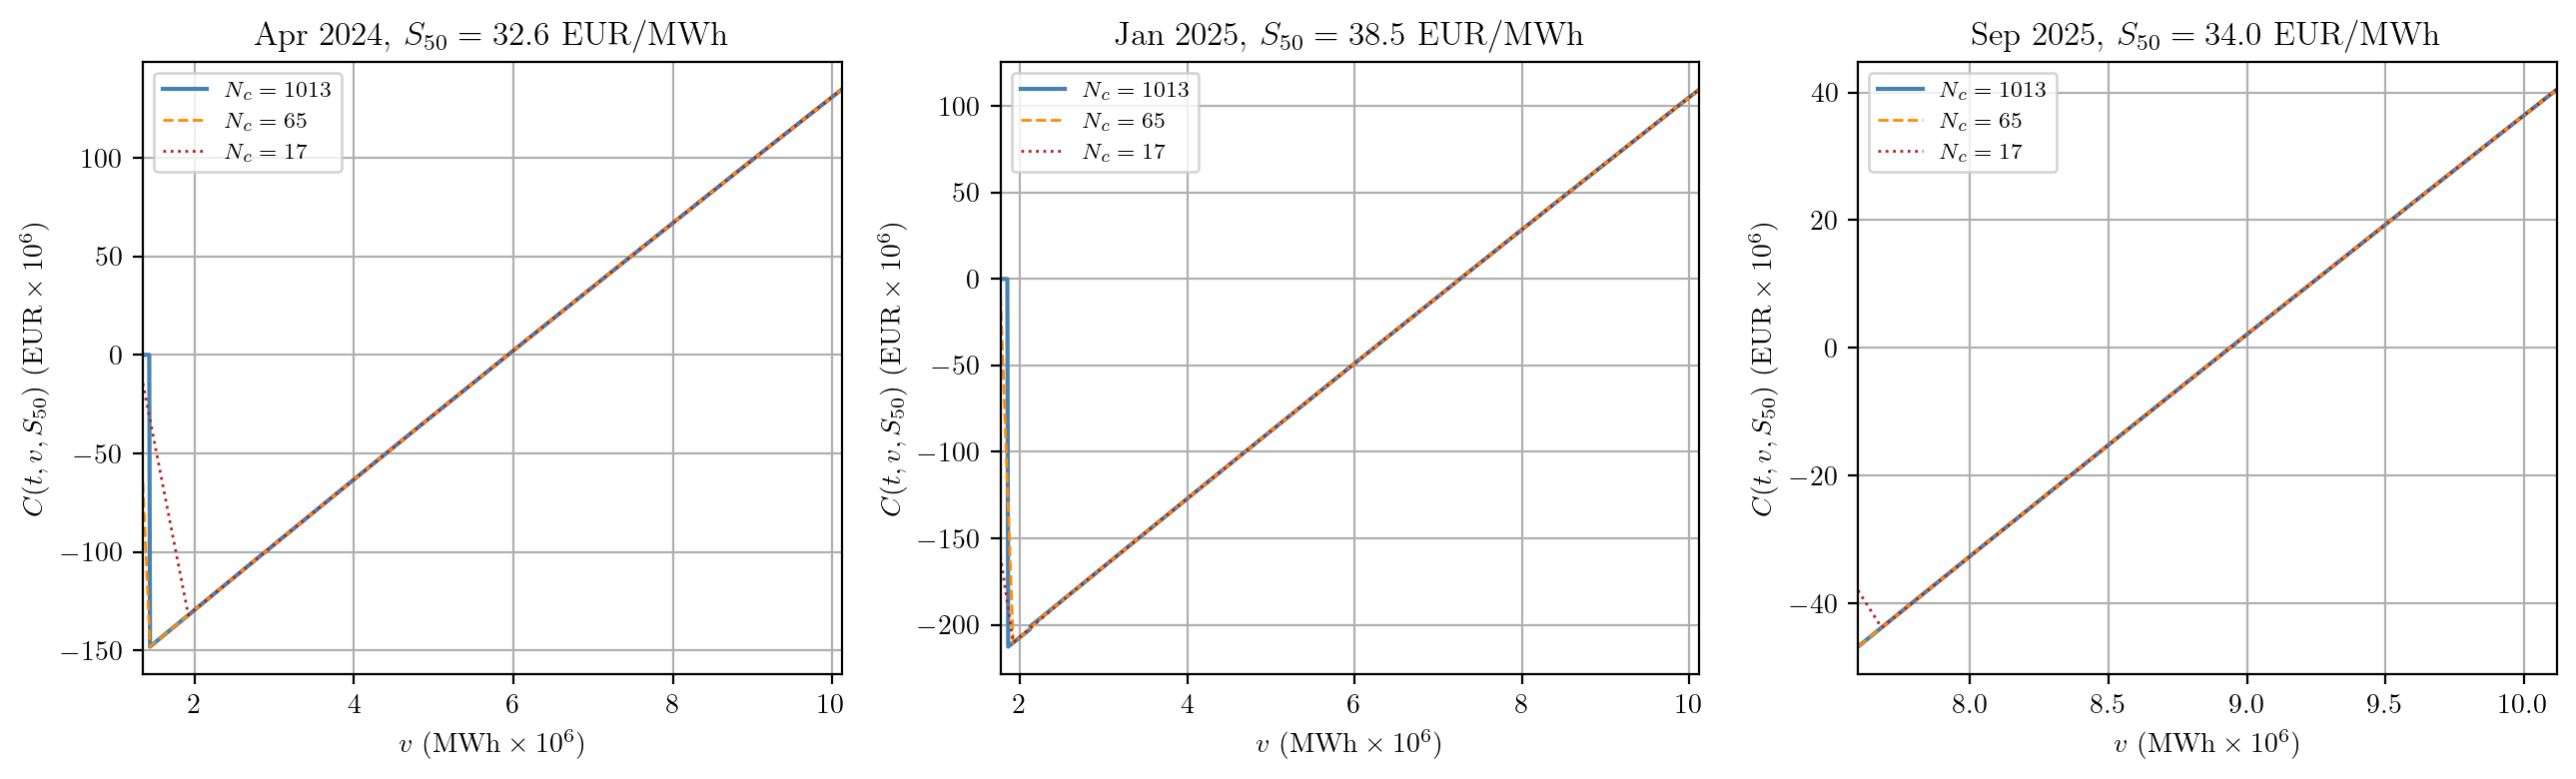


    Nc     alpha_c    Apr 2024 median err (EUR)  Jan 2025 median err (EUR)  Sep 2025 median err (EUR)
  1013      10,005                       0.00                     0.00                     0.00
   507      20,010                     167.68                   262.58                   165.94
   254      40,020                     324.55                   564.63                   494.80
   128      79,724                     520.86                 1,049.53                 1,101.98
    65     158,203                     857.40                 1,538.45                 1,246.08
    33     316,406                   1,726.73                 2,767.87                 3,910.07
    17     632,812                   5,672.64                 9,075.63                12,011.25


In [ ]:
# ============================================================
# Visualise C(t, v, S) in the v-dimension  — extended analysis
#
# Since k=1,2,4 lines were indistinguishable, push to much
# coarser grids (k up to 64, alpha_c up to ~640 000) and plot
# median interpolation error vs Nc to find where it starts to matter.
# Median over reachable fine-grid nodes is used instead of max
# to avoid distortion from the vmin boundary kink.
# ============================================================

def t_for_date(d_str):
    target = np.datetime64(d_str)
    idx    = int(np.searchsorted(data["date"].to_numpy(), target))
    return min(idx, B_store.shape[0] - 1)

t_picks  = [t_for_date("2024-04-01"),
            t_for_date("2025-01-01"),
            t_for_date("2025-09-01")]
t_labels = ["Apr 2024", "Jan 2025", "Sep 2025"]

# Subsampling factors to sweep — each k halves Nc approximately
k_sweep = [1, 2, 4, 8, 16, 32, 64]

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif":  ["Computer Modern Roman"],
})

# ---- per-timestep median interpolation error vs Nc ----
Nc_list  = []
err_mat  = np.zeros((len(t_picks), len(k_sweep)))

for ki, k_ in enumerate(k_sweep):
    sub_idx = np.arange(0, Nc, k_)
    if sub_idx[-1] != Nc - 1:
        sub_idx = np.append(sub_idx, Nc - 1)
    Nc_list.append(len(sub_idx))

    for ti, t_idx in enumerate(t_picks):
        S_t   = S_sim[t_idx]
        s_val = float(np.percentile(S_t, 50))
        s2, s3 = s_val ** 2, s_val ** 3
        reach = all_can_reach[t_idx]

        C_base = (B_store[t_idx, 0] + s_val * B_store[t_idx, 1]
                  + s2 * B_store[t_idx, 2] + s3 * B_store[t_idx, 3])

        C_fine_base = np.interp(v_fine, v_coarse, C_base)

        C_sub  = C_base[sub_idx]
        C_fine = np.interp(v_fine, v_coarse[sub_idx], C_sub)
        err_mat[ti, ki] = np.median(np.abs((C_fine - C_fine_base)[reach]))

# ---- Figure 1: median error vs Nc ----
fig1, (ax_err, ax_rel) = plt.subplots(1, 2, figsize=(6.5, 3.0), dpi=200)

colors_t = ["steelblue", "darkorange", "firebrick"]
for ti, (t_label, color) in enumerate(zip(t_labels, colors_t)):
    ax_err.plot(Nc_list, err_mat[ti] / 1e3,
                marker="o", color=color, lw=1.2, label=t_label)
    ax_rel.plot(Nc_list, 100 * err_mat[ti] / abs(V0_hat),
                marker="o", color=color, lw=1.2, label=t_label)

ax_err.set_xlabel(r"$N_c$ (coarse nodes)")
ax_err.set_ylabel(r"Median $|\Delta C|$ (EUR $\times 10^3$)")
ax_err.set_title(r"Median interpolation error at $S_{50}$")
ax_err.set_xscale("log")
ax_err.set_yscale("log")
ax_err.grid(True, which="both", ls="--", lw=0.5)
ax_err.legend(fontsize=8)

ax_rel.set_xlabel(r"$N_c$ (coarse nodes)")
ax_rel.set_ylabel(r"Median $|\Delta C|$ as \% of $\hat{V}_0$")
ax_rel.set_title(r"Relative to baseline value $\hat{V}_0$")
ax_rel.set_xscale("log")
ax_rel.set_yscale("log")
ax_rel.grid(True, which="both", ls="--", lw=0.5)

fig1.tight_layout()
plt.savefig("../../fig/Plots/OLS_C_vs_v_error_GSD.png")
plt.show()

# ---- Figure 2: C(v) curves for the three most extreme k values ----
k_plot   = [1, 16, 64]
lw_plot  = [1.5, 1.0, 1.0]
ls_plot  = ["-", "--", ":"]
col_plot = ["steelblue", "darkorange", "firebrick"]

fig2, axes = plt.subplots(1, 3, figsize=(13, 4.0), dpi=200)

for ax, t_idx, t_label in zip(axes, t_picks, t_labels):
    S_t   = S_sim[t_idx]
    reach = all_can_reach[t_idx]
    s_val = float(np.percentile(S_t, 50))
    s2, s3 = s_val ** 2, s_val ** 3

    C_base = (B_store[t_idx, 0] + s_val * B_store[t_idx, 1]
              + s2 * B_store[t_idx, 2] + s3 * B_store[t_idx, 3])

    for k_, lw, ls, color in zip(k_plot, lw_plot, ls_plot, col_plot):
        sub_idx = np.arange(0, Nc, k_)
        if sub_idx[-1] != Nc - 1:
            sub_idx = np.append(sub_idx, Nc - 1)
        Nc_sub = len(sub_idx)
        C_fine = np.interp(v_fine, v_coarse[sub_idx], C_base[sub_idx])
        C_plot = np.where(reach, C_fine, np.nan)
        ax.plot(v_fine / 1e6, C_plot / 1e6,
                color=color, lw=lw, ls=ls, label=fr"$N_c={Nc_sub}$")

    if reach.any():
        ax.set_xlim(v_fine[reach][0] / 1e6, v_fine[reach][-1] / 1e6)

    ax.set_xlabel(r"$v$ ($\mathrm{MWh} \times 10^6$)")
    ax.set_ylabel(r"$C(t, v, S_{50})$ ($\mathrm{EUR} \times 10^6$)")
    ax.set_title(fr"{t_label},  $S_{{50}}={s_val:.1f}$ EUR/MWh")
    ax.grid(True)
    ax.legend(fontsize=8)

fig2.tight_layout()
plt.savefig("../../fig/Plots/OLS_C_vs_v_curves_GSD.png")
plt.show()

# ---- summary table ----
print(f"\n{'Nc':>6}  {'alpha_c':>10}  ", end="")
for t_label in t_labels:
    print(f"  {t_label} median err (EUR)", end="")
print()
for ki, (k_, Nc_sub) in enumerate(zip(k_sweep, Nc_list)):
    alpha_c_equiv = (VMAX_GLOBAL - VMIN_GLOBAL) / (Nc_sub - 1) if Nc_sub > 1 else np.inf
    print(f"{Nc_sub:>6}  {alpha_c_equiv:>10,.0f}  ", end="")
    for ti in range(len(t_picks)):
        print(f"  {err_mat[ti, ki]:>23,.2f}", end="")
    print()


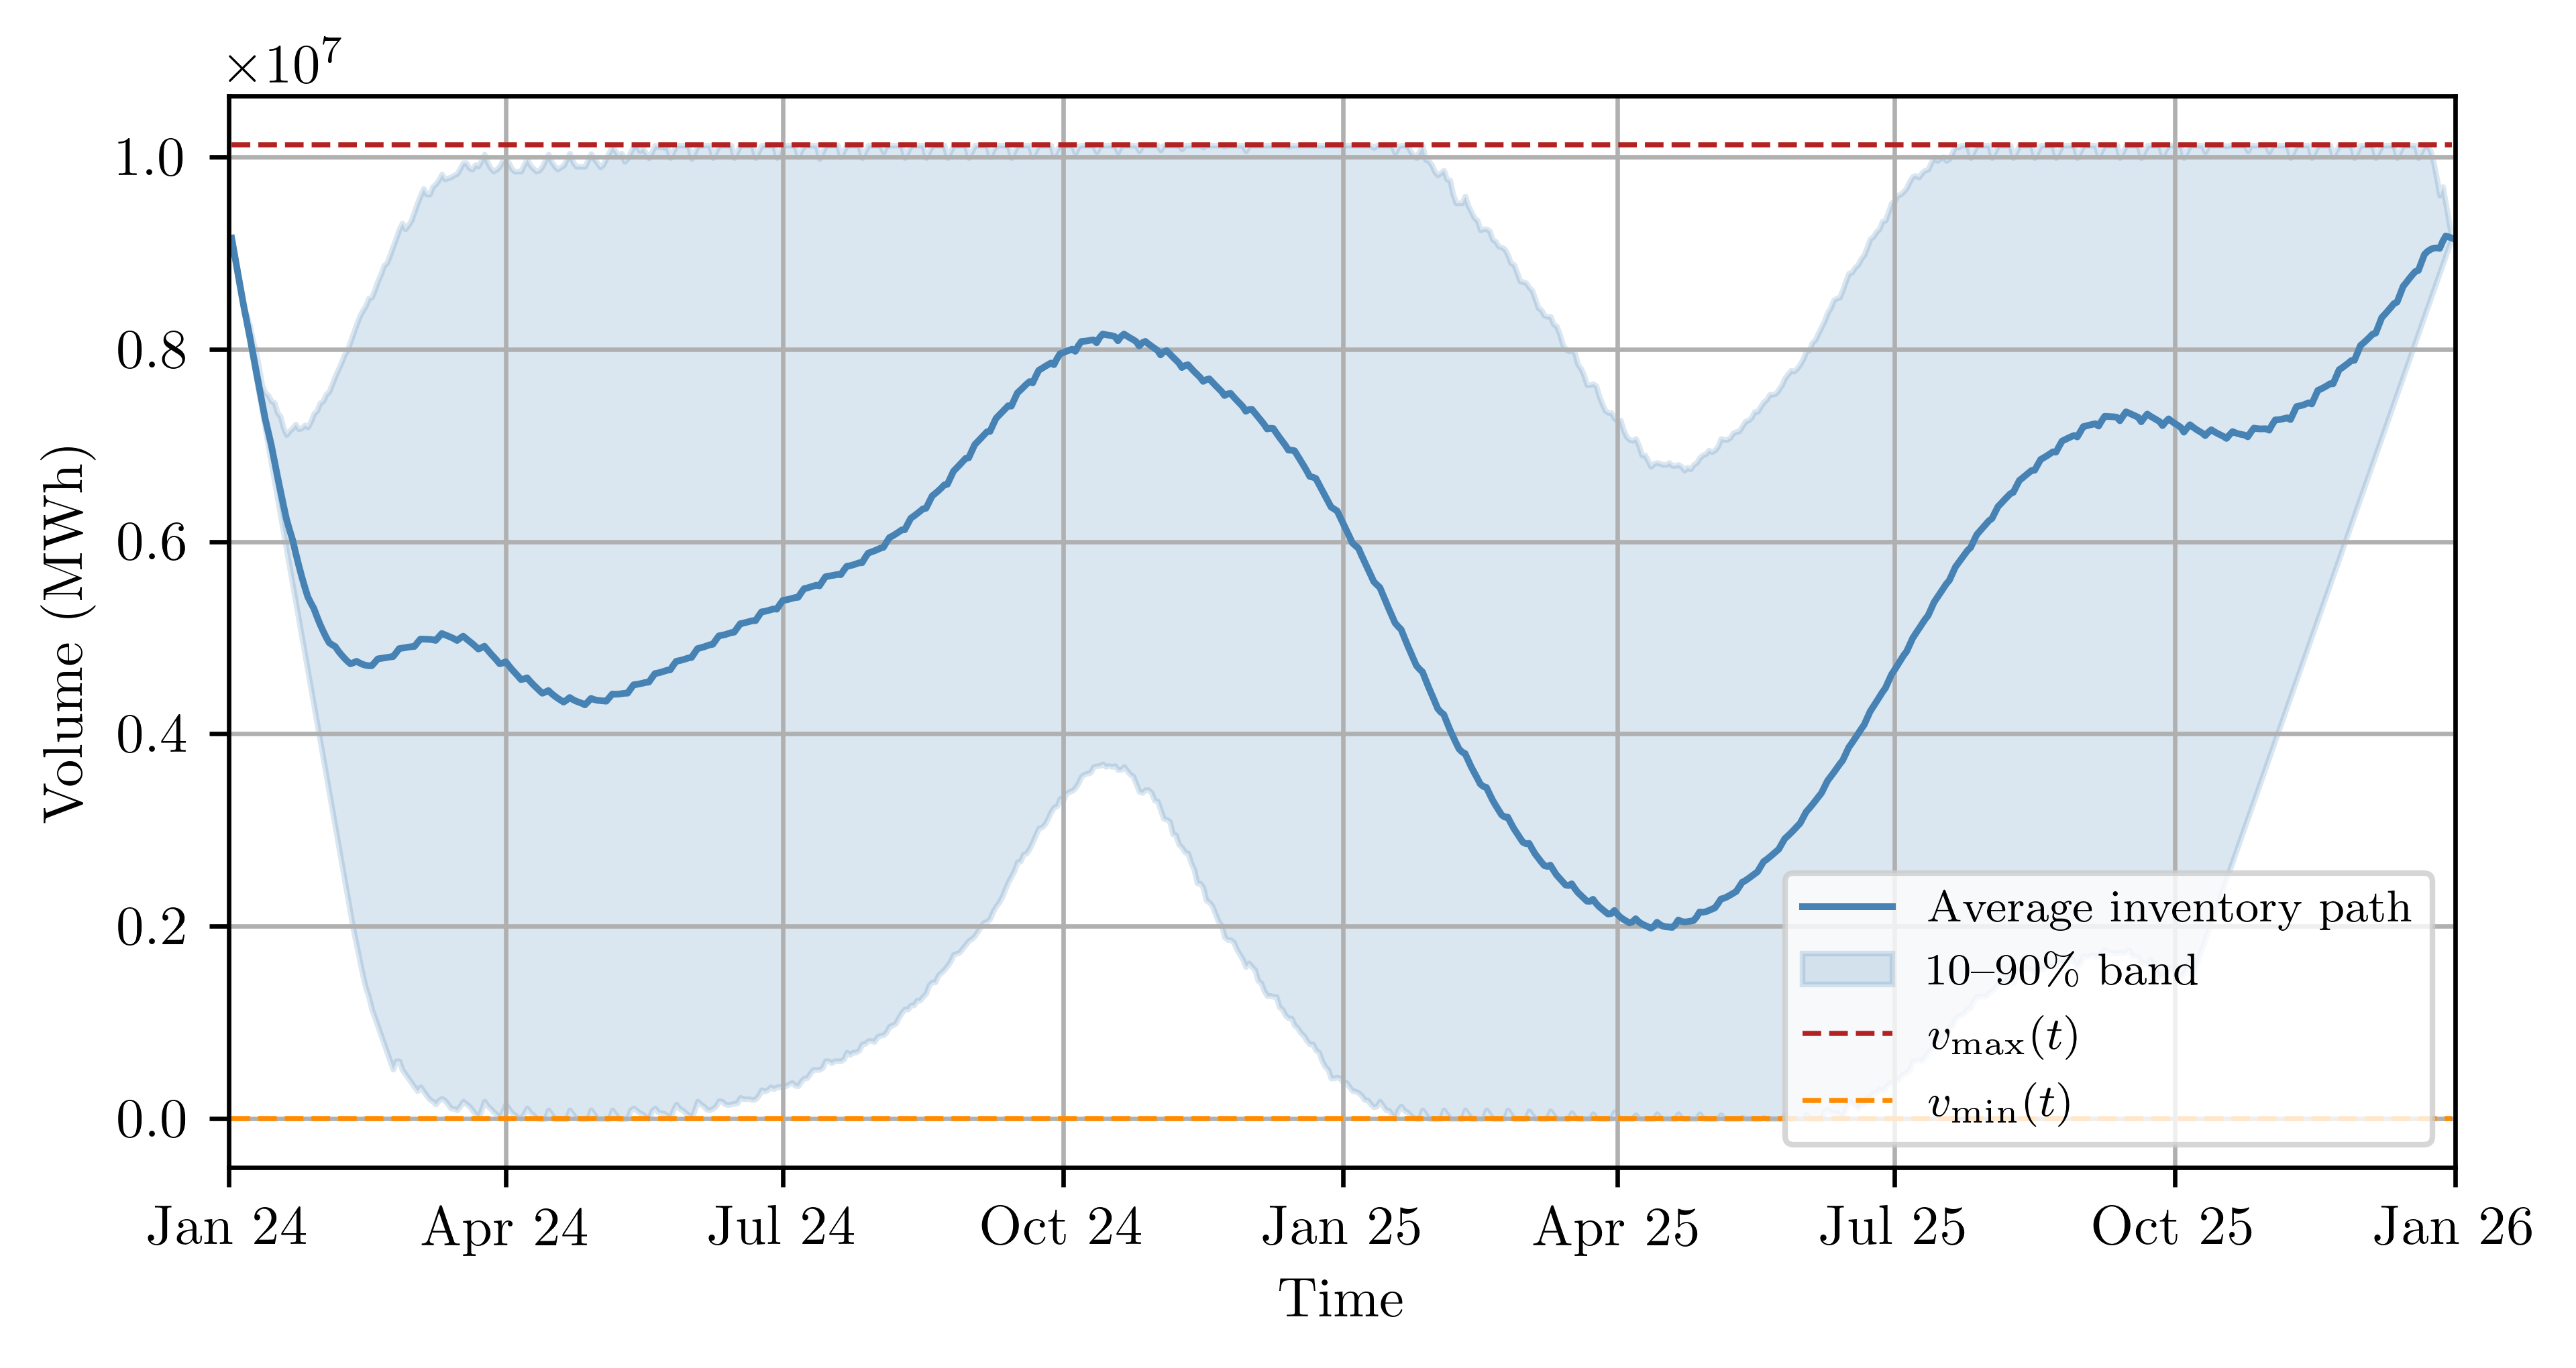

In [ ]:
avg_path = v_path.mean(axis=1)
p10      = np.percentile(v_path, 10, axis=1)
p90      = np.percentile(v_path, 90, axis=1)

dates_pd = pd.DatetimeIndex(dates)

x_start = pd.Timestamp("2024-01-01")
x_end   = pd.Timestamp("2026-01-01")

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif":  ["Computer Modern Roman"],
})

fig, ax = plt.subplots(figsize=(6.5, 3.5), dpi=600)

# Inventory paths
ax.plot(dates_pd, avg_path, color="steelblue", lw=1.2,
        label="Average inventory path")
ax.fill_between(dates_pd, p10, p90, alpha=0.2, color="steelblue",
                label=r"10--90\% band")

# Constraint curves — use the calendar-day arrays from cell 0 directly
ax.step(dates_pd, vmax_arr, where="post", color="firebrick",
        lw=0.9, ls="--", label=r"$v_{\max}(t)$")
ax.plot(dates_pd, vmin_arr, color="darkorange",
        lw=0.9, ls="--", label=r"$v_{\min}(t)$")

ax.set_xlabel("Time")
ax.set_ylabel("Volume (MWh)")
ax.grid(True)

tick_dates = pd.date_range(start=x_start, end=pd.Timestamp("2026-01-01"), freq="3MS")
ax.set_xlim(x_start, x_end)
ax.set_xticks([mdates.date2num(d) for d in tick_dates])
ax.set_xticklabels([d.strftime("%b %y") for d in tick_dates])

ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
plt.savefig("../../fig/Plots/OLS_realised_paths_GSD.png")
plt.show()

In [ ]:
# Calculate V0_hat_pathwise for each path using v_path and S_sim
dv_path = np.diff(v_path, axis=0)            # inventory change from t to t+1
cashflow = -S_sim[:-1] * dv_path            # buy -> negative, sell -> positive

# Discount each calendar-day step back to time 0.
disc_to_0 = np.concatenate(([1.0], np.cumprod(disc_arr[:-1])))
V0_hat_pathwise = np.sum(disc_to_0[:, None] * cashflow, axis=0)

# Plot frequency of V0_hat_pathwise
plt.figure(figsize=(10, 6))
plt.hist(V0_hat_pathwise, bins=50, alpha=1, color = "steelblue")
plt.axvline(V0_hat, color="black", linestyle="--", label=f"V0_hat = {V0_hat:.2f}")
plt.xlabel("Pathwise $\\hat{V}_0$ [EUR (millions)]")
plt.ylabel("Frequency")
plt.legend()
plt.grid()
plt.savefig("../../fig/Plots/OLS_V0_hat_distribution_GSD.png")
plt.show()

NameError: name 'np' is not defined

In [ ]:
# ============================================================
# Out-of-sample valuation using stored OLS coefficients
# ============================================================
def oos_value_from_B_store(S_test: np.ndarray, B_store: np.ndarray) -> float:
    """
    Evaluate V0 out-of-sample via forward simulation.

    The OLS continuation-value coefficients (B_store) come from a separate
    training run on S_train.  Here we roll the trained policy forward on fresh
    test paths S_test — no new regression is performed — recording the realised
    cashflows at each step and discounting them back to t=0.

    This avoids the look-ahead bias of the in-sample backward-DP estimate and
    gives a true lower bound on the storage value.
    """
    M = S_test.shape[1]

    ni_list       = nb.typed.List()
    dv_list       = nb.typed.List()
    kl_list       = nb.typed.List()
    reach_ok_list = nb.typed.List()
    for t in range(T):
        ni_list.append(all_next_idx[t])
        dv_list.append(all_dv_mat[t])
        kl_list.append(all_K_len[t])
        reach_ok_list.append(all_can_reach[t + 1])

    C_hat_fine_buf = np.empty((M, Nf), dtype=np.float64)
    n_path_idx = np.empty((T + 1, M), dtype=np.int32)
    forward_simulate_paths(
        n_path_idx, S_test, B_store, coarse_fine_idx, refine_factor,
        ni_list, dv_list, kl_list, reach_ok_list,
        n0_f, C_hat_fine_buf, terminal_penalty
    )

    # Realised cashflow at step t: sell/buy (v_{t+1} - v_t) MWh at price S_t.
    # Injection (dv > 0) costs -S_t * dv; withdrawal (dv < 0) earns -S_t * dv.
    dv_paths = v_fine[n_path_idx[1:]] - v_fine[n_path_idx[:-1]]   # (T, M)
    cf       = -S_test[:T] * dv_paths                              # (T, M)

    # Cumulative discount from t=0: cashflow at step t is multiplied by
    # disc_arr[0] * ... * disc_arr[t-1]  (cashflow at t=0 is undiscounted).
    cum_disc     = np.ones(T, dtype=np.float64)
    cum_disc[1:] = np.cumprod(disc_arr[:-1])

    pv = np.sum(cf * cum_disc[:, None], axis=0)   # (M,)

    # Paths that do not end at nT_f are infeasible — assign terminal penalty.
    at_target = (n_path_idx[T] == nT_f)
    n_failed  = int(np.sum(~at_target))
    if n_failed > 0:
        print(f"  OOS: {n_failed}/{M} paths did not reach terminal target.")
    pv[~at_target] = np.nan

    return float(np.nanmean(pv))


# ============================================================
# Run: train on S_sim, evaluate out-of-sample on S_test
# ============================================================
# Fresh test paths — independent seed, same antithetic structure
seed_oos   = seed + 1
rng_oos    = np.random.default_rng(seed_oos)
n_half_oos = int(np.ceil(n_paths_max / 2))
Z_half_oos = rng_oos.standard_normal(size=(Tn - 1, n_half_oos))
Z_oos      = np.concatenate([Z_half_oos, -Z_half_oos], axis=1)[:, :n_paths_max]
S_test     = simulate_from_Z(Z_oos, n_paths=n_paths_max, Tn=Tn, t_arr=t_arr,
                              kappa_hat=kappa_hat, sigma_hat=sigma_hat, m_col=m_col)

V0_hat_oos = oos_value_from_B_store(S_test, B_store)
print(f"V0_hat (out-of-sample) = {V0_hat_oos:,.2f}")